In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV


In [2]:
data = load_breast_cancer()
X,y = data.data,data.target

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9473684210526315


##Bagging

DecisionTreeClassifier Accuracy: 0.9474


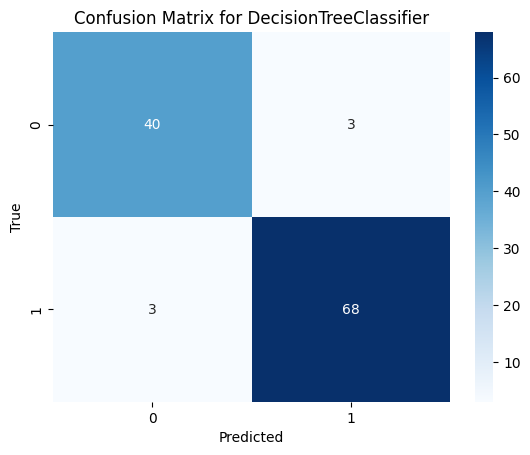

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to evaluate and print results
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model.__class__.__name__} Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Classification Report
    print(classification_report(y_test, y_pred))

# 1. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test)

# 2. Bagging with Decision Trees
bag = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=0.5,
    bootstrap=True,
    random_state=42
)
bag.fit(X_train, y_train)
evaluate_model(bag, X_test, y_test)

# 3. Bagging with SVM
bag_svm = BaggingClassifier(
    base_estimator=SVC(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42
)
bag_svm.fit(X_train, y_train)
evaluate_model(bag_svm, X_test, y_test)

# 4. Pasting (no bootstrap)
pasting = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=False,
    random_state=42,
    verbose=1,
    n_jobs=-1
)
pasting.fit(X_train, y_train)
evaluate_model(pasting, X_test, y_test)

# 5. Random Subspaces
random_subspaces = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=1.0,
    bootstrap=False,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)
random_subspaces.fit(X_train, y_train)
evaluate_model(random_subspaces, X_test, y_test)

# 6. Random Patches
random_patches = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    max_features=0.5,
    bootstrap_features=True,
    random_state=42
)
random_patches.fit(X_train, y_train)
evaluate_model(random_patches, X_test, y_test)

# 7. OOB Score
bag_oob = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
bag_oob.fit(X_train, y_train)
print("OOB Score:", bag_oob.oob_score_)
evaluate_model(bag_oob, X_test, y_test)

# 8. GridSearchCV for Bagging
params = {
    'n_estimators': [50, 100, 500],
    'max_samples': [0.1, 0.4, 0.7, 1.0],
    'bootstrap': [True, False],
    'max_features': [0.1, 0.4, 0.7, 1.0]
}
grid = GridSearchCV(BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42)), params, cv=5)
grid.fit(X_train, y_train)
print("Best GridSearch Params:", grid.best_params_)
print("Best GridSearch CV Score:", grid.best_score_)


In [ ]:
BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),  # The model to train
    n_estimators=500,                         # Number of base models
    max_samples=0.25,                         # % of rows to sample (25% in this case)
    max_features=0.5,                         # % of features to sample
    bootstrap=True,                           # Sampling rows *with* replacement
    bootstrap_features=True,                  # Sampling features *with* replacement
    oob_score=True,                           # Whether to calculate Out-of-Bag score
    random_state=42,                          # Ensures reproducibility
    n_jobs=-1,                                # Use all processors (parallel training)
    verbose=1                                 # Progress logs
)
# statistical proven one that 37 percent data never go to training in random samplind so it used as test data

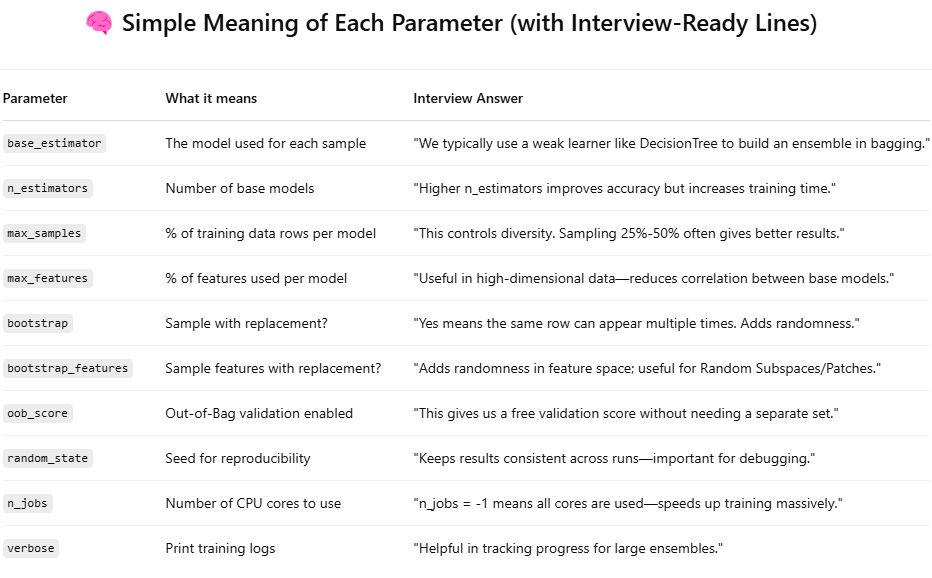

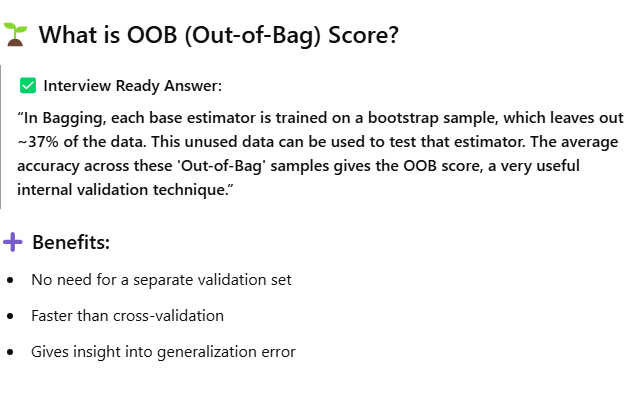

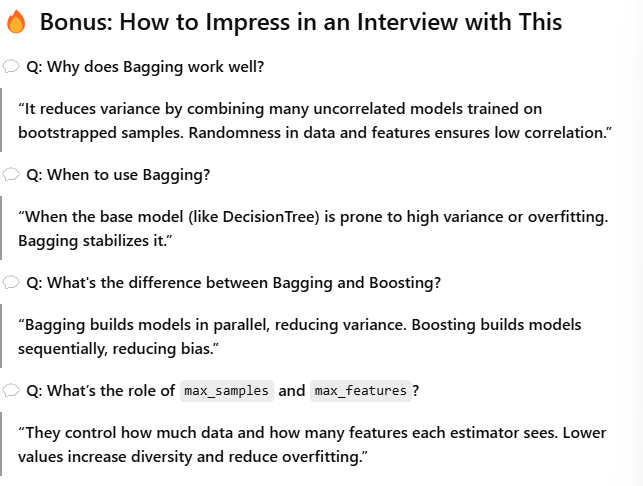


##2. Bagging Regressor

In [12]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load dataset
X, y = fetch_california_housing(return_X_y=True)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the Bagging Regressor
reg = BaggingRegressor(
    base_estimator=DecisionTreeRegressor(),  # Weak learner
    n_estimators=500,                        # Number of models
    max_samples=0.25,                        # 25% data per model
    max_features=0.5,                        # 50% features per model
    bootstrap=True,                          # Sample data with replacement
    bootstrap_features=True,                 # Sample features with replacement
    oob_score=True,                          # Out-of-Bag score for regression
    random_state=42,                         # Reproducible results
    n_jobs=-1,                               # Use all cores
    verbose=1                                # Show progress
)

# 4. Train the model
reg.fit(X_train, y_train)

# 5. Predictions
y_pred = reg.predict(X_test)

# 6. Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\n🔍 Test R² Score: {r2:.4f}")
print(f"🧮 Test MSE: {mse:.4f}")
print(f"📈 OOB Score: {reg.oob_score_:.4f}")


TypeError: BaggingRegressor.__init__() got an unexpected keyword argument 'base_estimator'

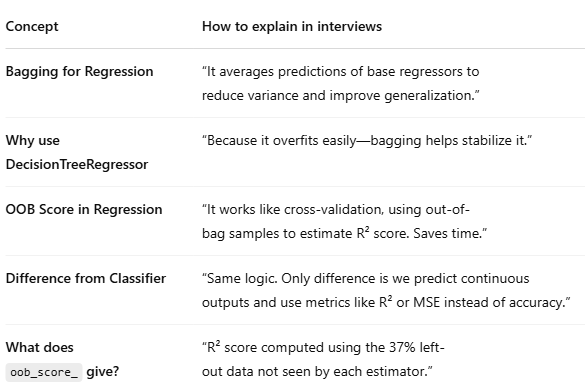

ValueError: x and y must be the same size

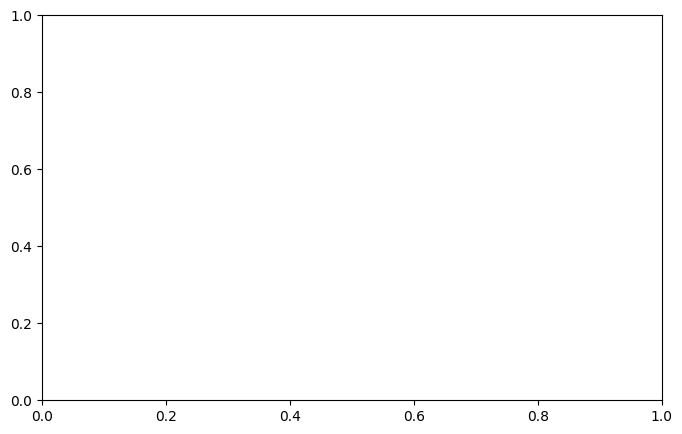

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Bagging Regressor - Actual vs Predicted")
plt.grid()
plt.show()


# 📘 Bagging: Why It Produces Better Results (with Interview Answers)

---

## 💡 How Bagging Produces Better Results

### 1. **Reduces Overfitting (High Variance)**
- Bagging trains multiple models on random subsets of the data (with replacement).
- Averaging (for regression) or majority voting (for classification) is used.
- Result: A stable and generalized model.

### 2. **Reduces Variance, Keeps Low Bias**
- Bagging helps models like Decision Trees, which have high variance.
- By averaging many noisy models, it reduces variance without increasing bias.

### 3. **Out-of-Bag (OOB) Evaluation**
- Every base model in Bagging sees about 63% of the training data.
- The remaining 37% becomes the “Out-of-Bag” sample.
- OOB score is a reliable internal validation metric — no need for cross-validation.

### 4. **Ensemble + Randomness = Power**
- Each estimator learns from different data.
- Less correlation between models = better results after aggregation.

---

## 🎯 Real-Life Analogy

> "Imagine 100 doctors diagnose you, each seeing different parts of your report. Some may be wrong, but averaging all opinions leads to a more accurate and stable decision."

---

## 🔥 Interview Q&A (Google-Style)

### Q1. Why does Bagging help improve model performance?
**A:**  
"Bagging reduces variance by combining multiple models trained on different data subsets. This ensemble method results in a more stable and accurate prediction, especially with models prone to overfitting like Decision Trees."

### Q2. What is the significance of the 63% and 37% in Bagging?
**A:**  
"In each bootstrapped dataset, roughly 63% of the training data is sampled with replacement. The remaining 37% acts as the Out-of-Bag (OOB) sample. We can use this to estimate generalization accuracy without a separate validation set."

### Q3. How does OOB score work?
**A:**  
"For every data point, we can evaluate it only on models that didn't see it during training. This forms the OOB score — a good proxy for test accuracy."

### Q4. How is Bagging different from Boosting?
**A:**  
"Bagging builds models independently and combines them. Boosting builds models sequentially, each correcting the previous one. Bagging reduces variance; Boosting reduces bias."

### Q5. When would you not use Bagging?
**A:**  
"If the base model is already low variance (e.g., linear regression), Bagging may not provide much benefit and can even lead to overfitting if the ensemble becomes too complex."

---

## 🔎 Bonus: When to Use Random Subspaces and Random Patches
- **Random Subspaces**: Effective when the dataset has many features (high dimensional).
- **Random Patches**: Combines row and column sampling, great for large and sparse data.

---

## 📊 Summary
- Bagging = Bootstrap + Aggregation
- Works best with high variance models
- OOB evaluation makes training efficient
- Improves generalization and reduces overfitting

